# Stage 3 Global LSTM Encoder (V3.x) Validation Notebook (Clean)

This notebook is designed to **work even if Lightning created multiple `logs/version_*` folders**.

It validates, per fold (rolling-origin CV):
1. File integrity and fold boundaries (no leakage).
2. Training curves and best epoch extraction.
3. Transfer learning evidence (Farm2107 → Global).
4. Window-level evaluation (model vs persistence baseline), aligned to the **same windows**.
5. Daytime or active-subset evaluation using **collate-safe metadata**.

If something is missing, the notebook prints a concrete error message and exits early.


In [1]:
# =========================
# 0) Imports and paths
# =========================
import os
import sys
from pathlib import Path
import math
import json

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Make plots readable
plt.rcParams["figure.figsize"] = (10, 4)

REPO_ROOT = Path.home() / "pv_forecast_30d"
DATA_DIR  = REPO_ROOT / "data" / "processed" / "pretraining" / "germany" / "global"
RUNS_DIR  = REPO_ROOT / "experiments" / "lstm" / "runs" / "germany" / "global_v3"
FARM2107_CKPT = REPO_ROOT / "experiments" / "lstm" / "encoders" / "lstm_encoder_farm2107_CANONICAL.pt"

# Rolling-origin folds that exist right now
FOLDS = [1, 2, 3, 4]
FOLD_MAP = {
    1: {"season": "Spring", "role": "CV"},
    2: {"season": "Summer", "role": "CV"},
    3: {"season": "Fall",   "role": "CV"},
    4: {"season": "Winter", "role": "CV"},
}

# Ensure repo imports work inside notebook
sys.path.insert(0, str(REPO_ROOT))

from src.data.schema import (
    TIME_COL, PLANT_ID_COL, TARGET_COL,
    LSTM_INPUT_FEATURES, GLOBAL_LSTM_INPUT_FEATURES, PLANT_ONEHOT_COLS,
    TIME_STEP_MINUTES
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("REPO_ROOT:", REPO_ROOT)
print("DATA_DIR :", DATA_DIR)
print("RUNS_DIR :", RUNS_DIR)
print("DEVICE   :", DEVICE)
print("Farm2107 ckpt exists:", FARM2107_CKPT.exists())
print("len(LSTM_INPUT_FEATURES):", len(LSTM_INPUT_FEATURES))
print("len(PLANT_ONEHOT_COLS)  :", len(PLANT_ONEHOT_COLS))
print("len(GLOBAL_LSTM_INPUT_FEATURES):", len(GLOBAL_LSTM_INPUT_FEATURES))


REPO_ROOT: /home/dwijenayake/pv_forecast_30d
DATA_DIR : /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global
RUNS_DIR : /home/dwijenayake/pv_forecast_30d/experiments/lstm/runs/germany/global_v3
DEVICE   : cuda
Farm2107 ckpt exists: True
len(LSTM_INPUT_FEATURES): 15
len(PLANT_ONEHOT_COLS)  : 5
len(GLOBAL_LSTM_INPUT_FEATURES): 20


In [2]:
# =========================
# 1) File integrity audit
# =========================
def must_exist(p: Path) -> bool:
    ok = p.exists()
    print(("OK  " if ok else "MISS"), str(p))
    return ok

def find_latest_file(root: Path, pattern: str) -> Path | None:
    """Return newest file matching pattern under root, or None."""
    cands = list(root.rglob(pattern))
    if not cands:
        return None
    return max(cands, key=lambda p: p.stat().st_mtime)

all_ok = True

# Fold data
for k in FOLDS:
    all_ok &= must_exist(DATA_DIR / f"fold_{k}_train.parquet")
    all_ok &= must_exist(DATA_DIR / f"fold_{k}_val.parquet")

# Models + metrics
for k in FOLDS:
    fold_dir = RUNS_DIR / f"fold_{k}"
    all_ok &= must_exist(fold_dir / f"lstm_encoder_global_fold_{k}.pt")

    m = find_latest_file(fold_dir, "metrics.csv")
    print(("OK  " if m else "MISS"), str(m) if m else str(fold_dir / "**/metrics.csv"))
    all_ok &= (m is not None)

print("\nALL FILES OK:", all_ok)
if not all_ok:
    raise SystemExit("Fix missing files first (paths above).")


OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_1_train.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_1_val.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_2_train.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_2_val.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_3_train.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_3_val.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_4_train.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_4_val.parquet
OK   /home/dwijenayake/pv_forecast_30d/experiments/lstm/runs/germany/global_v3/fold_1/lstm_encoder_global_fold_1.pt
OK   /home/dwijenayake/pv_forecast_30d/experiments/lstm/runs/germany/global_

In [3]:
# =========================
# 2) Fold boundary and leakage checks
# =========================
def leakage_check(tr: pd.DataFrame, va: pd.DataFrame, k: int) -> dict:
    """Check for timestamp overlap and (plant_id, timestamp) overlap."""
    tr_max = tr[TIME_COL].max()
    va_min = va[TIME_COL].min()
    overlap_time = len(set(tr[TIME_COL]).intersection(set(va[TIME_COL])))
    overlap_keys = len(set(zip(tr[PLANT_ID_COL], tr[TIME_COL])).intersection(set(zip(va[PLANT_ID_COL], va[TIME_COL]))))
    return {
        "fold": k,
        "train_rows": len(tr),
        "val_rows": len(va),
        "train_start": str(tr[TIME_COL].min()),
        "train_end": str(tr_max),
        "val_start": str(va_min),
        "val_end": str(va[TIME_COL].max()),
        "gap_minutes": float((va_min - tr_max).total_seconds() / 60.0),
        "overlap_time_rows": int(overlap_time),
        "overlap_key_rows": int(overlap_keys),
        "train_plants": int(tr[PLANT_ID_COL].nunique()),
        "val_plants": int(va[PLANT_ID_COL].nunique()),
    }

audit_rows = []
for k in FOLDS:
    tr = pd.read_parquet(DATA_DIR / f"fold_{k}_train.parquet")
    va = pd.read_parquet(DATA_DIR / f"fold_{k}_val.parquet")
    audit_rows.append(leakage_check(tr, va, k))

audit_df = pd.DataFrame(audit_rows).sort_values("fold")
audit_df


,fold,train_rows,val_rows,train_start,train_end,val_start,val_end,gap_minutes,overlap_time_rows,overlap_key_rows,train_plants,val_plants
0,1,22672,35328,2022-12-31 23:00:00+00:00,2023-02-28 23:45:00+00:00,2023-03-01 00:00:00+00:00,2023-05-31 23:45:00+00:00,15.0,0,0,4,4
1,2,58000,35326,2022-12-31 23:00:00+00:00,2023-05-31 23:45:00+00:00,2023-06-01 00:00:00+00:00,2023-08-31 23:45:00+00:00,15.0,0,0,4,4
2,3,99285,43674,2022-12-31 23:00:00+00:00,2023-08-31 23:45:00+00:00,2023-09-01 00:00:00+00:00,2023-11-30 23:45:00+00:00,15.0,0,0,5,5
3,4,142959,37720,2022-12-31 23:00:00+00:00,2023-11-30 23:45:00+00:00,2023-12-01 00:00:00+00:00,2024-02-29 23:45:00+00:00,15.0,0,0,5,5


In [4]:
# Hard fail if leakage is detected
bad = audit_df[(audit_df["overlap_key_rows"] > 0) | (audit_df["gap_minutes"] < 0)]
if len(bad):
    display(bad)
    raise SystemExit("Leakage detected: overlap between train and val. Fix fold generator before trusting metrics.")
else:
    print("Leakage checks PASSED (no overlap, non-negative gap).")


Leakage checks PASSED (no overlap, non-negative gap).


In [5]:
# =========================
# 3) Read metrics correctly (Lightning logs/version_*/metrics.csv)
# =========================
def read_metrics_csv_for_fold(k: int) -> tuple[Path, pd.DataFrame]:
    fold_dir = RUNS_DIR / f"fold_{k}"
    p = find_latest_file(fold_dir, "metrics.csv")
    if p is None:
        raise FileNotFoundError(f"No metrics.csv under {fold_dir}")
    df = pd.read_csv(p)
    # Normalize epoch column if needed
    if "epoch" not in df.columns and "step" in df.columns:
        df["epoch"] = df["step"]
    return p, df

def reduce_metrics_per_epoch(df: pd.DataFrame) -> pd.DataFrame:
    """Keep last non-NaN values per epoch for key columns."""
    d = df.copy()
    d["epoch"] = pd.to_numeric(d["epoch"], errors="coerce")
    d = d.dropna(subset=["epoch"]).sort_values(["epoch"])
    cols = [c for c in ["train_loss_epoch", "val_loss"] if c in d.columns]
    if not cols:
        return d[["epoch"]].drop_duplicates()
    out = (d.groupby("epoch", as_index=False)[cols].last())
    return out

def best_epoch_by_val_loss(df_epoch: pd.DataFrame) -> pd.Series:
    d = df_epoch.dropna(subset=["val_loss"]).copy()
    if len(d) == 0:
        return pd.Series(dtype=float)
    return d.loc[d["val_loss"].astype(float).idxmin()]

rows = []
for k in FOLDS:
    p, df = read_metrics_csv_for_fold(k)
    df_e = reduce_metrics_per_epoch(df)
    best = best_epoch_by_val_loss(df_e)
    if best.empty:
        rows.append({"fold": k, "metrics_path": str(p)})
        continue

    train_loss = float(best.get("train_loss_epoch", np.nan))
    val_loss = float(best.get("val_loss", np.nan))

    train_rmse = math.sqrt(train_loss) if np.isfinite(train_loss) else np.nan
    val_rmse = math.sqrt(val_loss) if np.isfinite(val_loss) else np.nan
    ratio = (train_rmse / val_rmse) if (np.isfinite(train_rmse) and np.isfinite(val_rmse) and val_rmse > 0) else np.nan

    rows.append({
        "fold": k,
        "season": FOLD_MAP[k]["season"],
        "role": FOLD_MAP[k]["role"],
        "best_epoch": int(best["epoch"]),
        "best_train_loss": train_loss,
        "best_val_loss": val_loss,
        "train_rmse": train_rmse,
        "val_rmse": val_rmse,
        "train_val_ratio": ratio,
        "metrics_path": str(p),
    })

fold_metrics_df = pd.DataFrame(rows).sort_values("fold")
fold_metrics_df


,fold,season,role,best_epoch,best_train_loss,best_val_loss,train_rmse,val_rmse,train_val_ratio,metrics_path
0,1,Spring,CV,13,0.000977,0.005868,0.031265,0.076602,0.408144,/home/dwijenayake/pv_forecast_30d/experiments/...
1,2,Summer,CV,19,0.003445,0.005470,0.058690,0.073962,0.793524,/home/dwijenayake/pv_forecast_30d/experiments/...
2,3,Fall,CV,17,0.004027,0.001710,0.063455,0.041353,1.534496,/home/dwijenayake/pv_forecast_30d/experiments/...
3,4,Winter,CV,9,0.003362,0.000461,0.057983,0.021471,2.700545,/home/dwijenayake/pv_forecast_30d/experiments/...


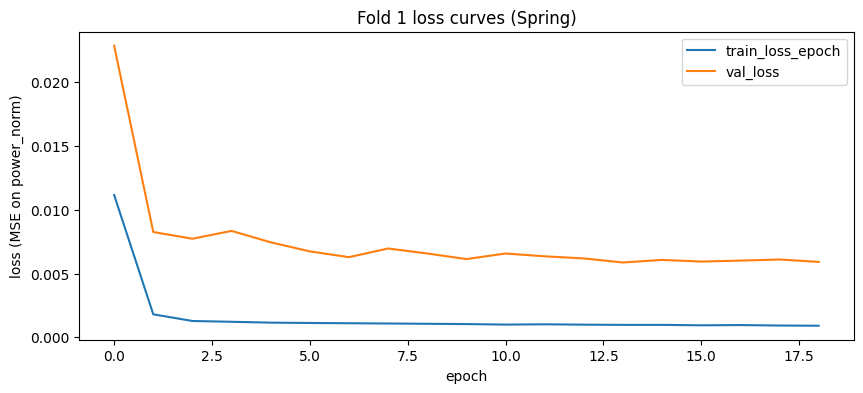

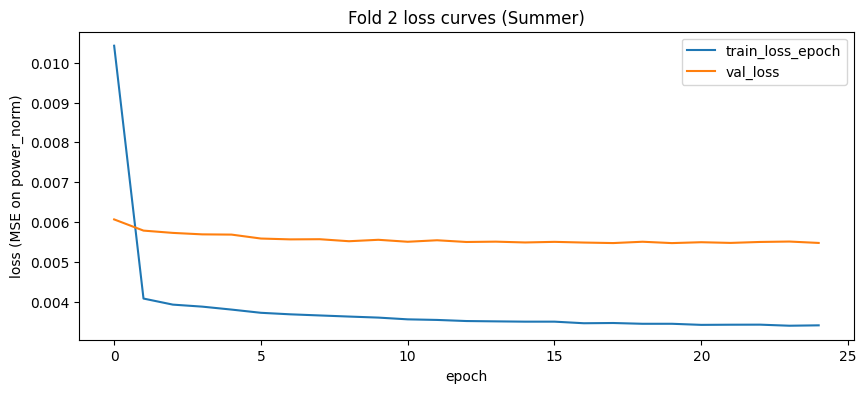

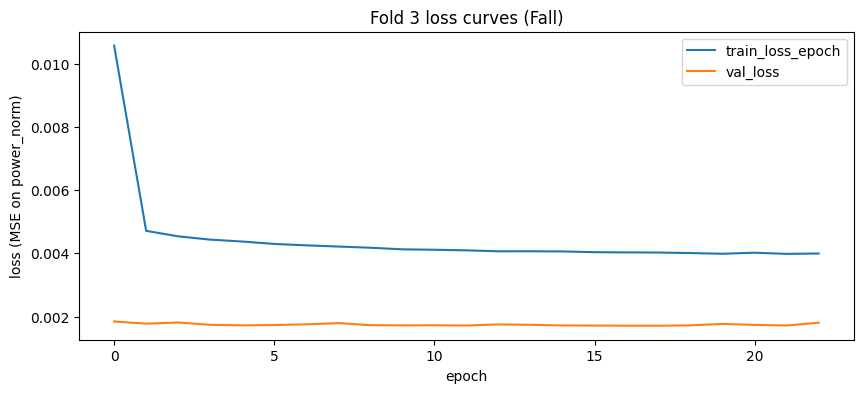

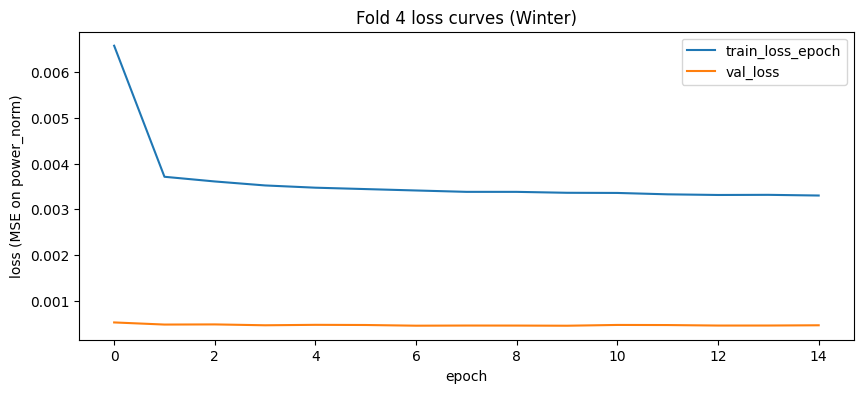

In [6]:
# =========================
# 4) Plot loss curves (not empty)
# =========================
for k in FOLDS:
    p, df = read_metrics_csv_for_fold(k)
    df_e = reduce_metrics_per_epoch(df)
    if "val_loss" not in df_e.columns:
        print(f"[WARN] Fold {k}: no val_loss in {p}")
        continue

    fig = plt.figure()
    x = df_e["epoch"].to_numpy()
    if "train_loss_epoch" in df_e.columns:
        plt.plot(x, df_e["train_loss_epoch"].to_numpy(), label="train_loss_epoch")
    plt.plot(x, df_e["val_loss"].to_numpy(), label="val_loss")
    plt.title(f"Fold {k} loss curves ({FOLD_MAP[k]['season']})")
    plt.xlabel("epoch")
    plt.ylabel("loss (MSE on power_norm)")
    plt.legend()
    plt.show()


In [7]:
# =========================
# 5) Transfer learning evidence (Farm2107 → Global)
# =========================
from src.models.global_lstm_encoder import GlobalLSTMEncoder, LSTMEncoderConfig

def load_state_dict_any(p: Path) -> dict:
    """Load a PyTorch state dict from .pt or a Lightning checkpoint."""
    obj = torch.load(p, map_location="cpu")
    if isinstance(obj, dict) and "state_dict" in obj:
        # lightning ckpt
        sd = obj["state_dict"]
        # strip possible 'model.' prefixes if they exist
        return {k.replace("model.", ""): v for k, v in sd.items()}
    if isinstance(obj, dict):
        return obj
    raise ValueError(f"Unrecognized checkpoint format: {p}")

def cosine(a: torch.Tensor, b: torch.Tensor) -> float:
    a = a.flatten().float()
    b = b.flatten().float()
    return float(torch.nn.functional.cosine_similarity(a, b, dim=0).cpu().numpy())

farm_sd = load_state_dict_any(FARM2107_CKPT)

transfer_rows = []
for k in FOLDS:
    fold_sd = load_state_dict_any(RUNS_DIR / f"fold_{k}" / f"lstm_encoder_global_fold_{k}.pt")

    # These keys must match your model definition. Adjust only if key names differ.
    W_farm = farm_sd["lstm.weight_ih_l0"]          # (4H, 15)
    W_fold = fold_sd["lstm.weight_ih_l0"]          # (4H, 20)

    # Similarity on shared feature columns 0..14
    sim = cosine(W_farm, W_fold[:, :15])

    # Plant-id weights are columns 15..19
    plant_block = W_fold[:, 15:20]
    transfer_rows.append({
        "fold": k,
        "season": FOLD_MAP[k]["season"],
        "cosine_similarity_cols0_14": sim,
        "plant_weight_mean_abs": float(plant_block.abs().mean().cpu().numpy()),
        "plant_weight_std": float(plant_block.float().std().cpu().numpy()),
    })

transfer_df = pd.DataFrame(transfer_rows).sort_values("fold")
transfer_df


/tmp/ipykernel_443015/640741535.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(p, map_location="cpu")


,fold,season,cosine_similarity_cols0_14,plant_weight_mean_abs,plant_weight_std
0,1,Spring,0.995169,0.009757,0.013443
1,2,Summer,0.985436,0.019768,0.028067
2,3,Fall,0.981029,0.040393,0.058173
3,4,Winter,0.984153,0.038147,0.054469


## Window-level evaluation (model vs persistence)

Important details:
- We evaluate **on the same windows** your training dataset uses.
- Persistence baseline for a window is `power_norm[t-1]`, which is the last `power_norm` inside the input window.
- This evaluation avoids the earlier bug where a day-threshold was applied to normalized irradiance.

We report:
- RMSE on all windows
- RMSE on "active" windows where target `power_norm > 0.02`

If you later want a physical "day" mask using irradiance in raw units, add it only after you confirm you can inverse-transform that column correctly.


In [8]:
# =========================
# 6) Collate-safe evaluation dataset with metadata
# =========================
from torch.utils.data import Dataset, DataLoader

class EvalGroupedWindowDataset(Dataset):
    """
    Sliding-window dataset per plant_id, collate-safe.

    Returns:
      X: float32 tensor (window_size, n_features)
      y: float32 tensor scalar (target at time t)
      pid: int64 tensor (plant index)
      t: int64 tensor (unix seconds for target time)
      persist: float32 tensor scalar (power_norm at t-1, last value in window)
    """

    def __init__(self, df: pd.DataFrame, window_size: int = 96, stride: int = 1):
        self.window_size = int(window_size)
        self.stride = int(stride)

        d = df.copy()
        d[TIME_COL] = pd.to_datetime(d[TIME_COL], utc=True)
        d = d.sort_values([PLANT_ID_COL, TIME_COL]).reset_index(drop=True)

        self.plants = sorted(d[PLANT_ID_COL].unique().tolist())
        self.pid_to_idx = {p: i for i, p in enumerate(self.plants)}

        required = set([TIME_COL, PLANT_ID_COL, TARGET_COL] + GLOBAL_LSTM_INPUT_FEATURES)
        missing = sorted(required - set(d.columns))
        if missing:
            raise ValueError(f"EvalGroupedWindowDataset missing columns: {missing}")

        # Hard fail on NaNs
        if np.isnan(d[GLOBAL_LSTM_INPUT_FEATURES].to_numpy()).any() or np.isnan(d[TARGET_COL].to_numpy()).any():
            raise ValueError("NaNs detected in eval fold data. Fix preprocessing before evaluation.")

        self._by_pid = {}
        self._index = []  # (pid_idx, start_i)

        freq_s = int(TIME_STEP_MINUTES * 60)

        for plant_id, g in d.groupby(PLANT_ID_COL, sort=True):
            g = g.sort_values(TIME_COL).reset_index(drop=True)

            times = (g[TIME_COL].astype("int64").to_numpy() // 10**9).astype(np.int64)  # unix seconds
            X = g[GLOBAL_LSTM_INPUT_FEATURES].to_numpy(dtype=np.float32)
            y = g[TARGET_COL].to_numpy(dtype=np.float32)

            if len(g) <= self.window_size:
                continue

            diffs = np.diff(times)
            good_step = (diffs == freq_s)

            max_start = len(g) - self.window_size - 1
            pid_idx = self.pid_to_idx[plant_id]

            for i in range(0, max_start + 1, self.stride):
                if good_step[i : i + self.window_size].all():
                    self._index.append((pid_idx, i))

            self._by_pid[pid_idx] = {"X": X, "y": y, "t": times}

        if len(self._index) == 0:
            raise ValueError("No valid windows produced. Check time regularity and window_size.")

    def __len__(self):
        return len(self._index)

    def __getitem__(self, idx):
        pid_idx, i = self._index[idx]
        X = self._by_pid[pid_idx]["X"][i : i + self.window_size]
        y = self._by_pid[pid_idx]["y"][i + self.window_size]
        t = self._by_pid[pid_idx]["t"][i + self.window_size]

        # persistence baseline: last power_norm in the input window
        persist = X[-1, 0]  # power_norm is first feature

        return (
            torch.from_numpy(X),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(pid_idx, dtype=torch.int64),
            torch.tensor(t, dtype=torch.int64),
            torch.tensor(persist, dtype=torch.float32),
        )


In [9]:
# =========================
# 7) Evaluate a fold (model output is a dict)
# =========================
def rmse(a: np.ndarray, b: np.ndarray) -> float:
    a = a.astype(float)
    b = b.astype(float)
    return float(np.sqrt(np.mean((a - b) ** 2)))

def evaluate_fold_windows(k: int, window_size: int = 96, batch_size: int = 512, num_workers: int = 2, active_thr: float = 0.02) -> dict:
    """
    Evaluate fold model on window-aligned targets.

    Returns overall and active-window RMSE for:
      - model predictions
      - persistence baseline (power_norm[t-1])
    """
    va = pd.read_parquet(DATA_DIR / f"fold_{k}_val.parquet")
    ds = EvalGroupedWindowDataset(va, window_size=window_size, stride=1)

    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    # Build model and load weights
    cfg = LSTMEncoderConfig(
        input_size=len(GLOBAL_LSTM_INPUT_FEATURES),
        hidden_size=64,
        num_layers=2,
        dropout=0.1,
        lr=1e-4,
    )
    model = GlobalLSTMEncoder(cfg).to(DEVICE)
    sd = torch.load(RUNS_DIR / f"fold_{k}" / f"lstm_encoder_global_fold_{k}.pt", map_location=DEVICE)
    model.load_state_dict(sd)
    model.eval()

    preds = []
    ys = []
    persists = []
    pid_idx = []
    tts = []

    with torch.no_grad():
        for X, y, pid, tt, persist in loader:
            X = X.to(DEVICE)
            out = model(X)

            # IMPORTANT: model forward returns dict: {'next_pred': ..., 'embedding': ...}
            yhat = out["next_pred"].detach().cpu().numpy().reshape(-1)

            preds.append(yhat)
            ys.append(y.cpu().numpy().reshape(-1))
            persists.append(persist.cpu().numpy().reshape(-1))
            pid_idx.append(pid.cpu().numpy().reshape(-1))
            tts.append(tt.cpu().numpy().reshape(-1))

    yhat = np.concatenate(preds)
    ytrue = np.concatenate(ys)
    ypers = np.concatenate(persists)

    active = (ytrue > active_thr)
    out = {
        "fold": k,
        "season": FOLD_MAP[k]["season"],
        "n_windows": int(len(ytrue)),
        "n_active_windows": int(active.sum()),
        "model_rmse_all": rmse(yhat, ytrue),
        "persist_rmse_all": rmse(ypers, ytrue),
        "model_rmse_active": rmse(yhat[active], ytrue[active]) if active.any() else np.nan,
        "persist_rmse_active": rmse(ypers[active], ytrue[active]) if active.any() else np.nan,
    }
    return out

# Quick single-fold smoke test (set num_workers=0 if debugging DataLoader)
evaluate_fold_windows(1, window_size=96, batch_size=512, num_workers=2)


[INFO] GlobalLSTMEncoder initialized:
  Input size: 20 (15 original + 5 plant IDs)
  Hidden size: 64
  Num layers: 2
  Dropout: 0.1


/tmp/ipykernel_443015/1108763449.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(RUNS_DIR / f"fold_{k}" / f"lstm_encoder_global_fold_{k}.pt", map_locati

{'fold': 1,
 'season': 'Spring',
 'n_windows': 34944,
 'n_active_windows': 16752,
 'model_rmse_all': 0.07688911133872724,
 'persist_rmse_all': 0.07695055069013478,
 'model_rmse_active': 0.10702035223511659,
 'persist_rmse_active': 0.10829241988098469}

In [10]:
# Run all folds
results = []
for k in FOLDS:
    results.append(evaluate_fold_windows(k, window_size=96, batch_size=512, num_workers=2, active_thr=0.02))

win_eval_df = pd.DataFrame(results).sort_values("fold")
win_eval_df


[INFO] GlobalLSTMEncoder initialized:
  Input size: 20 (15 original + 5 plant IDs)
  Hidden size: 64
  Num layers: 2
  Dropout: 0.1


/tmp/ipykernel_443015/1108763449.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(RUNS_DIR / f"fold_{k}" / f"lstm_encoder_global_fold_{k}.pt", map_locati

[INFO] GlobalLSTMEncoder initialized:
  Input size: 20 (15 original + 5 plant IDs)
  Hidden size: 64
  Num layers: 2
  Dropout: 0.1


/tmp/ipykernel_443015/1108763449.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(RUNS_DIR / f"fold_{k}" / f"lstm_encoder_global_fold_{k}.pt", map_locati

[INFO] GlobalLSTMEncoder initialized:
  Input size: 20 (15 original + 5 plant IDs)
  Hidden size: 64
  Num layers: 2
  Dropout: 0.1


/tmp/ipykernel_443015/1108763449.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(RUNS_DIR / f"fold_{k}" / f"lstm_encoder_global_fold_{k}.pt", map_locati

[INFO] GlobalLSTMEncoder initialized:
  Input size: 20 (15 original + 5 plant IDs)
  Hidden size: 64
  Num layers: 2
  Dropout: 0.1


/tmp/ipykernel_443015/1108763449.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(RUNS_DIR / f"fold_{k}" / f"lstm_encoder_global_fold_{k}.pt", map_locati

,fold,season,n_windows,n_active_windows,model_rmse_all,persist_rmse_all,model_rmse_active,persist_rmse_active
0,1,Spring,34944,16752,0.076889,0.076951,0.107020,0.108292
1,2,Summer,34750,19699,0.073988,0.082069,0.096710,0.108063
2,3,Fall,43097,15640,0.042489,0.045019,0.068983,0.073613
3,4,Winter,36952,9653,0.021689,0.023164,0.041516,0.044683


In [11]:
# =========================
# 8) Compare training-curve RMSE (from best val_loss) vs window-eval RMSE
# =========================
merged = fold_metrics_df.merge(win_eval_df, on=["fold", "season"], how="left")
merged[[
    "fold","season",
    "val_rmse","train_val_ratio",
    "model_rmse_all","persist_rmse_all",
    "model_rmse_active","persist_rmse_active",
    "n_windows","n_active_windows"
]]


,fold,season,val_rmse,train_val_ratio,model_rmse_all,persist_rmse_all,model_rmse_active,persist_rmse_active,n_windows,n_active_windows
0,1,Spring,0.076602,0.408144,0.076889,0.076951,0.107020,0.108292,34944,16752
1,2,Summer,0.073962,0.793524,0.073988,0.082069,0.096710,0.108063,34750,19699
2,3,Fall,0.041353,1.534496,0.042489,0.045019,0.068983,0.073613,43097,15640
3,4,Winter,0.021471,2.700545,0.021689,0.023164,0.041516,0.044683,36952,9653


## Interpretation guide (fast and blunt)

- If **model_rmse_all is not better than persist_rmse_all**, your LSTM is not adding value (yet).
- Active-window metrics matter more for PV, because nights dominate and are easy.
- If your curve-based `val_rmse` looks tiny but window-eval RMSE is larger, you are probably:
  - comparing different targets, or
  - evaluating on different subsets, or
  - mixing normalized vs raw thresholds in your filtering.


In [12]:
# =========================
# 9) Next steps checklist (print-only)
# =========================
def next_steps_reco(df: pd.DataFrame) -> None:
    """Print actionable next steps based on metrics."""
    for _, r in df.iterrows():
        k = int(r["fold"])
        better_all = r["model_rmse_all"] < r["persist_rmse_all"]
        better_act = (np.isfinite(r["model_rmse_active"]) and np.isfinite(r["persist_rmse_active"]) and (r["model_rmse_active"] < r["persist_rmse_active"]))
        print(f"Fold {k} ({r['season']}):")
        print(f"  All windows: model {r['model_rmse_all']:.4f} vs persist {r['persist_rmse_all']:.4f} -> {'OK' if better_all else 'BAD'}")
        if np.isfinite(r["model_rmse_active"]):
            print(f"  Active only: model {r['model_rmse_active']:.4f} vs persist {r['persist_rmse_active']:.4f} -> {'OK' if better_act else 'BAD'}")
        else:
            print("  Active only: not enough active windows, check fold or threshold.")
        print()

next_steps_reco(win_eval_df)


Fold 1 (Spring):
  All windows: model 0.0769 vs persist 0.0770 -> OK
  Active only: model 0.1070 vs persist 0.1083 -> OK

Fold 2 (Summer):
  All windows: model 0.0740 vs persist 0.0821 -> OK
  Active only: model 0.0967 vs persist 0.1081 -> OK

Fold 3 (Fall):
  All windows: model 0.0425 vs persist 0.0450 -> OK
  Active only: model 0.0690 vs persist 0.0736 -> OK

Fold 4 (Winter):
  All windows: model 0.0217 vs persist 0.0232 -> OK
  Active only: model 0.0415 vs persist 0.0447 -> OK



# FINAL CHECK 1: verify which plants exist per fold and why some are missing


In [13]:
"""
Quick audit: which plant_ids appear in each fold train/val,
and whether any plant is missing due to time coverage (not a bug).
"""

import pandas as pd
from collections import defaultdict

def fold_plant_coverage(k: int):
    tr = pd.read_parquet(DATA_DIR / f"fold_{k}_train.parquet", columns=[PLANT_ID_COL, TIME_COL])
    va = pd.read_parquet(DATA_DIR / f"fold_{k}_val.parquet",   columns=[PLANT_ID_COL, TIME_COL])

    out = {
        "fold": k,
        "train_plants": sorted(tr[PLANT_ID_COL].unique().tolist()),
        "val_plants":   sorted(va[PLANT_ID_COL].unique().tolist()),
        "train_min_time": str(tr[TIME_COL].min()),
        "train_max_time": str(tr[TIME_COL].max()),
        "val_min_time":   str(va[TIME_COL].min()),
        "val_max_time":   str(va[TIME_COL].max()),
    }

    # per-plant row counts, quick view
    tr_counts = tr[PLANT_ID_COL].value_counts().to_dict()
    va_counts = va[PLANT_ID_COL].value_counts().to_dict()

    # make a compact table
    plants = sorted(set(tr_counts) | set(va_counts))
    rows = []
    for p in plants:
        rows.append({
            "fold": k,
            "plant_id": p,
            "train_rows": int(tr_counts.get(p, 0)),
            "val_rows": int(va_counts.get(p, 0)),
        })
    counts_df = pd.DataFrame(rows).sort_values(["fold", "plant_id"])
    return out, counts_df

summaries = []
counts_all = []

for k in FOLDS:
    s, c = fold_plant_coverage(k)
    summaries.append(s)
    counts_all.append(c)

display(pd.DataFrame(summaries))
display(pd.concat(counts_all, ignore_index=True))


,fold,train_plants,val_plants,train_min_time,train_max_time,val_min_time,val_max_time
0,1,"[plant_01, plant_02, plant_03, plant_06]","[plant_01, plant_02, plant_03, plant_06]",2022-12-31 23:00:00+00:00,2023-02-28 23:45:00+00:00,2023-03-01 00:00:00+00:00,2023-05-31 23:45:00+00:00
1,2,"[plant_01, plant_02, plant_03, plant_06]","[plant_01, plant_02, plant_03, plant_06]",2022-12-31 23:00:00+00:00,2023-05-31 23:45:00+00:00,2023-06-01 00:00:00+00:00,2023-08-31 23:45:00+00:00
2,3,"[plant_01, plant_02, plant_03, plant_05, plant...","[plant_01, plant_02, plant_03, plant_05, plant...",2022-12-31 23:00:00+00:00,2023-08-31 23:45:00+00:00,2023-09-01 00:00:00+00:00,2023-11-30 23:45:00+00:00
3,4,"[plant_01, plant_02, plant_03, plant_05, plant...","[plant_01, plant_02, plant_03, plant_05, plant...",2022-12-31 23:00:00+00:00,2023-11-30 23:45:00+00:00,2023-12-01 00:00:00+00:00,2024-02-29 23:45:00+00:00


,fold,plant_id,train_rows,val_rows
0,1,plant_01,5668,8832
1,1,plant_02,5668,8832
2,1,plant_03,5668,8832
3,1,plant_06,5668,8832
4,2,plant_01,14500,8831
5,2,plant_02,14500,8831
6,2,plant_03,14500,8832
7,2,plant_06,14500,8832
8,3,plant_01,23331,8736
9,3,plant_02,23331,8736


# FINAL CHECK 2: verify GTI is normalized in fold parquets (and show raw GTI via inverse transform if available)

In [14]:
"""
Quick audit: check whether global_tilted_irradiance_instant is z-scored in fold data.
If scaler stats exist and include GTI, also reconstruct raw GTI min/max.
"""

import json
import numpy as np
import pandas as pd

GTI_COL = "global_tilted_irradiance_instant"

def load_scaler_obj(k: int):
    p = DATA_DIR / f"fold_{k}_scaler.json"
    if not p.exists():
        return None, str(p)
    with open(p, "r", encoding="utf-8") as f:
        obj = json.load(f)
    return obj, str(p)

def get_stats(obj):
    # supports {"stats": {...}} or flat {col: {...}}
    if obj is None:
        return None
    if isinstance(obj, dict) and "stats" in obj:
        return obj["stats"]
    return obj

def inverse_z(x, mu, sd):
    return x.astype(float) * float(sd) + float(mu)

for k in FOLDS:
    va = pd.read_parquet(DATA_DIR / f"fold_{k}_val.parquet", columns=[GTI_COL, PLANT_ID_COL, TIME_COL])
    g = va[GTI_COL].astype(float)

    obj, scaler_path = load_scaler_obj(k)
    stats = get_stats(obj)

    print("\n" + "="*80)
    print(f"Fold {k} GTI audit")
    print("="*80)
    print("Val GTI (as stored) min/max:", float(np.nanmin(g)), float(np.nanmax(g)))
    print("Scaler json path:", scaler_path, "exists:", obj is not None)

    if stats is not None and GTI_COL in stats:
        mu = stats[GTI_COL]["mean"]
        sd = stats[GTI_COL]["std"]
        g_raw = inverse_z(g, mu, sd)
        print("Val GTI (reconstructed RAW) min/max:", float(np.nanmin(g_raw)), float(np.nanmax(g_raw)))
        print("RAW GTI > 10 rows:", int((g_raw > 10.0).sum()))
    else:
        print("[INFO] No scaler stats for GTI in this fold, cannot inverse-transform here.")



Fold 1 GTI audit
Val GTI (as stored) min/max: -0.5700547348254867 14.578052832293913
Scaler json path: /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_1_scaler.json exists: True
Val GTI (reconstructed RAW) min/max: 0.0 719.7259
RAW GTI > 10 rows: 19262

Fold 2 GTI audit
Val GTI (as stored) min/max: -0.620538104978984 4.28801909096108
Scaler json path: /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_2_scaler.json exists: True
Val GTI (reconstructed RAW) min/max: 0.0 739.93054
RAW GTI > 10 rows: 22212

Fold 3 GTI audit
Val GTI (as stored) min/max: -0.7295557065427001 1.982850816113528
Scaler json path: /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_3_scaler.json exists: True
Val GTI (reconstructed RAW) min/max: 0.0 498.28976
RAW GTI > 10 rows: 18071

Fold 4 GTI audit
Val GTI (as stored) min/max: -0.671514157251241 1.06078921798217
Scaler json path: /home/dwijenayake/pv_forecast_30d/data/p